In [ ]:
!pip install simpy scikit-learn matplotlib seaborn openpyxl xgboost imbalanced-learn -q

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
import simpy
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import StandardScaler as _SS2
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import precision_recall_curve
import heapq
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
COLAB_PATH = '/content/drive/MyDrive/air quality/AirQualityUCI.xlsx'

LOCAL_PATH = 'AirQualityUCI.xlsx'
FILE_PATH = COLAB_PATH if os.path.exists(COLAB_PATH) else LOCAL_PATH

In [ ]:
raw_df = pd.read_excel(FILE_PATH, sheet_name=0)
print(f'Raw shape: {raw_df.shape}')
print('\nFirst 5 rows:')
raw_df.head()

Raw shape: (9357, 15)

First 5 rows:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [ ]:
PALETTE = {
    'blue':   '#4C9BE8',
    'green':  '#4CE8A0',
    'orange': '#E8A04C',
    'pink':   '#E84C9B',
    'purple': '#9B4CE8',
    'red':    '#E84C4C',
    'teal':   '#4CE8D4',
    'lime':   '#B8E84C',
}
FEAT_COLORS = [PALETTE['blue'], PALETTE['green'], PALETTE['orange'], PALETTE['pink']]
PROTO_COLORS = {'MQTT': PALETTE['blue'], 'CoAP': PALETTE['orange']}

# Professional academic color palette
ACADEMIC_COLORS = {
    'blue':    '#2E5A88',   # deep muted blue (normal class)
    'red':     '#8B3A3A',   # muted burgundy (anomaly class)
    'green':   '#3A7D44',   # forest green (recall)
    'orange':  '#B85C1A',   # burnt orange (F1/ensemble)
    'purple':  '#6A4C8C',   # muted purple (PR curve)
    'teal':    '#2C7A6E',   # muted teal
    'gray':    '#6B6B6B',   # neutral gray
    'navy':    '#1B3A5C',   # dark navy (cumulative line)
}

PALETTE = {
    'blue':   ACADEMIC_COLORS['blue'],
    'red':    ACADEMIC_COLORS['red'],
    'green':  ACADEMIC_COLORS['green'],
    'orange': ACADEMIC_COLORS['orange'],
    'purple': ACADEMIC_COLORS['purple'],
    'teal':   ACADEMIC_COLORS['teal'],
    'gray':   ACADEMIC_COLORS['gray'],
}

PROTO_COLORS = {
    'MQTT': ACADEMIC_COLORS['blue'],
    'CoAP': ACADEMIC_COLORS['teal'],
}

FEAT_COLORS = [ACADEMIC_COLORS['blue'], ACADEMIC_COLORS['teal'], ACADEMIC_COLORS['green'],
               ACADEMIC_COLORS['orange'], ACADEMIC_COLORS['purple'], ACADEMIC_COLORS['gray']]

PALETTE = {
    'raw':     ACADEMIC_COLORS['blue'],     # instead of red
    'encoded': ACADEMIC_COLORS['green'],    # keep green but muted
}

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    10,
    'legend.framealpha': 0.85,
    'figure.dpi':        120,
})

In [ ]:
print('Columns:', raw_df.columns.tolist())
print('\nData types:')
print(raw_df.dtypes)
print('\nMissing values per column:')
print(raw_df.isnull().sum())

Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Data types:
Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                  int64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

Missing values per column:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dt

In [ ]:
df = raw_df.copy()

df.dropna(how='all', axis=0, inplace=True)
df.dropna(how='all', axis=1, inplace=True)

df.replace(-200, np.nan, inplace=True)

# Selecting the 4 main sensor features
col_map = {}
for col in df.columns:
    c = str(col).strip()
    if 'CO(GT)' in c:    col_map[col] = 'CO'
    elif c == 'T':       col_map[col] = 'Temperature'
    elif 'RH' in c:      col_map[col] = 'Humidity'
    elif 'NOx(GT)' in c: col_map[col] = 'NOx'
    elif 'Date' in c:    col_map[col] = 'Date'
    elif 'Time' in c:    col_map[col] = 'Time'

df.rename(columns=col_map, inplace=True)

keep_cols = [c for c in ['Date','Time','CO','Temperature','Humidity','NOx'] if c in df.columns]
df = df[keep_cols].copy()

feature_cols = [c for c in ['CO','Temperature','Humidity','NOx'] if c in df.columns]
df.dropna(subset=feature_cols, how='all', inplace=True)

# Linear interpolation for realistic sensor dropout
df[feature_cols] = df[feature_cols].interpolate(method='linear').ffill().bfill()

df.reset_index(drop=True, inplace=True)

print(f'Cleaned dataset shape: {df.shape}')
print(f'Features used: {feature_cols}')
print('\nSample:')
df.head(8)

Cleaned dataset shape: (9326, 6)
Features used: ['CO', 'Temperature', 'Humidity', 'NOx']

Sample:


,Date,Time,CO,Temperature,Humidity,NOx
0,2004-03-10,18:00:00,2.6,13.600,48.875001,166.0
1,2004-03-10,19:00:00,2.0,13.300,47.700000,103.0
2,2004-03-10,20:00:00,2.2,11.900,53.975000,131.0
3,2004-03-10,21:00:00,2.2,11.000,60.000000,172.0
4,2004-03-10,22:00:00,1.6,11.150,59.575001,131.0
5,2004-03-10,23:00:00,1.2,11.175,59.175000,89.0
6,2004-03-11,00:00:00,1.2,11.325,56.775000,62.0
7,2004-03-11,01:00:00,1.0,10.675,60.000000,62.0


In [ ]:
warnings.filterwarnings('ignore')

for feat in feature_cols:
    for w in [5, 15, 30, 60]:
        df[f'{feat}_rmean_{w}'] = df[feat].rolling(w, min_periods=1).mean()
        df[f'{feat}_rstd_{w}']  = df[feat].rolling(w, min_periods=1).std().fillna(0)
        df[f'{feat}_rmin_{w}']  = df[feat].rolling(w, min_periods=1).min()
        df[f'{feat}_rmax_{w}']  = df[feat].rolling(w, min_periods=1).max()
    # Lag features
    df[f'{feat}_lag1']   = df[feat].shift(1).bfill()
    df[f'{feat}_lag3']   = df[feat].shift(3).bfill()
    df[f'{feat}_lag6']   = df[feat].shift(6).bfill()
    df[f'{feat}_lag12']  = df[feat].shift(12).bfill()
    # Rate of change
    df[f'{feat}_diff1']  = df[feat].diff().fillna(0)
    df[f'{feat}_diff2']  = df[feat].diff().diff().fillna(0)
    df[f'{feat}_diff3']  = df[feat].diff().diff().diff().fillna(0)
    # Statistical
    df[f'{feat}_zscore'] = (df[feat] - df[feat].mean()) / (df[feat].std() + 1e-9)
    df[f'{feat}_dev30']  = df[feat] - df[feat].rolling(30, min_periods=1).mean()
    df[f'{feat}_dev60']  = df[feat] - df[feat].rolling(60, min_periods=1).mean()
    # Exponential moving average
    df[f'{feat}_ema5']   = df[feat].ewm(span=5,  adjust=False).mean()
    df[f'{feat}_ema15']  = df[feat].ewm(span=15, adjust=False).mean()
    df[f'{feat}_ema30']  = df[feat].ewm(span=30, adjust=False).mean()
    # Deviation from EMA
    df[f'{feat}_dev_ema5'] = df[feat] - df[f'{feat}_ema5']
    # Percentile rank
    df[f'{feat}_rank']   = df[feat].rank(pct=True)

# Cross-sensor interactions
if 'CO' in df.columns and 'NOx' in df.columns:
    df['CO_NOx_ratio']   = df['CO'] / (df['NOx'].replace(0, np.nan)).fillna(1)
    df['CO_NOx_product'] = df['CO'] * df['NOx']
    df['CO_NOx_diff']    = df['CO'] - df['NOx']
    df['CO_NOx_sum']     = df['CO'] + df['NOx']
if 'Temperature' in df.columns and 'Humidity' in df.columns:
    df['heat_index']     = df['Temperature'] * df['Humidity'] / 100.0
    df['temp_hum_diff']  = df['Temperature'] - df['Humidity']
if 'CO' in df.columns and 'Temperature' in df.columns:
    df['CO_Temp_ratio']  = df['CO'] / (df['Temperature'].replace(0, np.nan)).fillna(1)
    df['CO_Temp_product']= df['CO'] * df['Temperature']

# Hour-of-day cyclical encoding
if 'Time' in df.columns:
    try:
        hours = pd.to_datetime(df['Time'], errors='coerce').dt.hour.fillna(0)
        df['hour_sin'] = np.sin(2 * np.pi * hours / 24)
        df['hour_cos'] = np.cos(2 * np.pi * hours / 24)
    except Exception:
        pass

feature_cols_extended = [c for c in df.columns if c not in ['Date','Time','is_anomaly']]
print(f'Extended feature set: {len(feature_cols_extended)} features')
print(feature_cols_extended)

Extended feature set: 138 features
['CO', 'Temperature', 'Humidity', 'NOx', 'CO_rmean_5', 'CO_rstd_5', 'CO_rmin_5', 'CO_rmax_5', 'CO_rmean_15', 'CO_rstd_15', 'CO_rmin_15', 'CO_rmax_15', 'CO_rmean_30', 'CO_rstd_30', 'CO_rmin_30', 'CO_rmax_30', 'CO_rmean_60', 'CO_rstd_60', 'CO_rmin_60', 'CO_rmax_60', 'CO_lag1', 'CO_lag3', 'CO_lag6', 'CO_lag12', 'CO_diff1', 'CO_diff2', 'CO_diff3', 'CO_zscore', 'CO_dev30', 'CO_dev60', 'CO_ema5', 'CO_ema15', 'CO_ema30', 'CO_dev_ema5', 'CO_rank', 'Temperature_rmean_5', 'Temperature_rstd_5', 'Temperature_rmin_5', 'Temperature_rmax_5', 'Temperature_rmean_15', 'Temperature_rstd_15', 'Temperature_rmin_15', 'Temperature_rmax_15', 'Temperature_rmean_30', 'Temperature_rstd_30', 'Temperature_rmin_30', 'Temperature_rmax_30', 'Temperature_rmean_60', 'Temperature_rstd_60', 'Temperature_rmin_60', 'Temperature_rmax_60', 'Temperature_lag1', 'Temperature_lag3', 'Temperature_lag6', 'Temperature_lag12', 'Temperature_diff1', 'Temperature_diff2', 'Temperature_diff3', 'Temperat

In [ ]:
print('Statistical Summary:')
print(df[feature_cols].describe().round(2))

Statistical Summary:
            CO  Temperature  Humidity      NOx
count  9326.00      9326.00   9326.00  9326.00
mean      2.13        18.21     49.26   241.81
std       1.43         8.79     17.17   204.56
min       0.10        -1.90      9.18     2.00
25%       1.09        11.68     35.98    95.35
50%       1.80        17.53     49.68   179.45
75%       2.90        24.24     62.30   325.95
max      11.90        44.60     88.73  1479.00


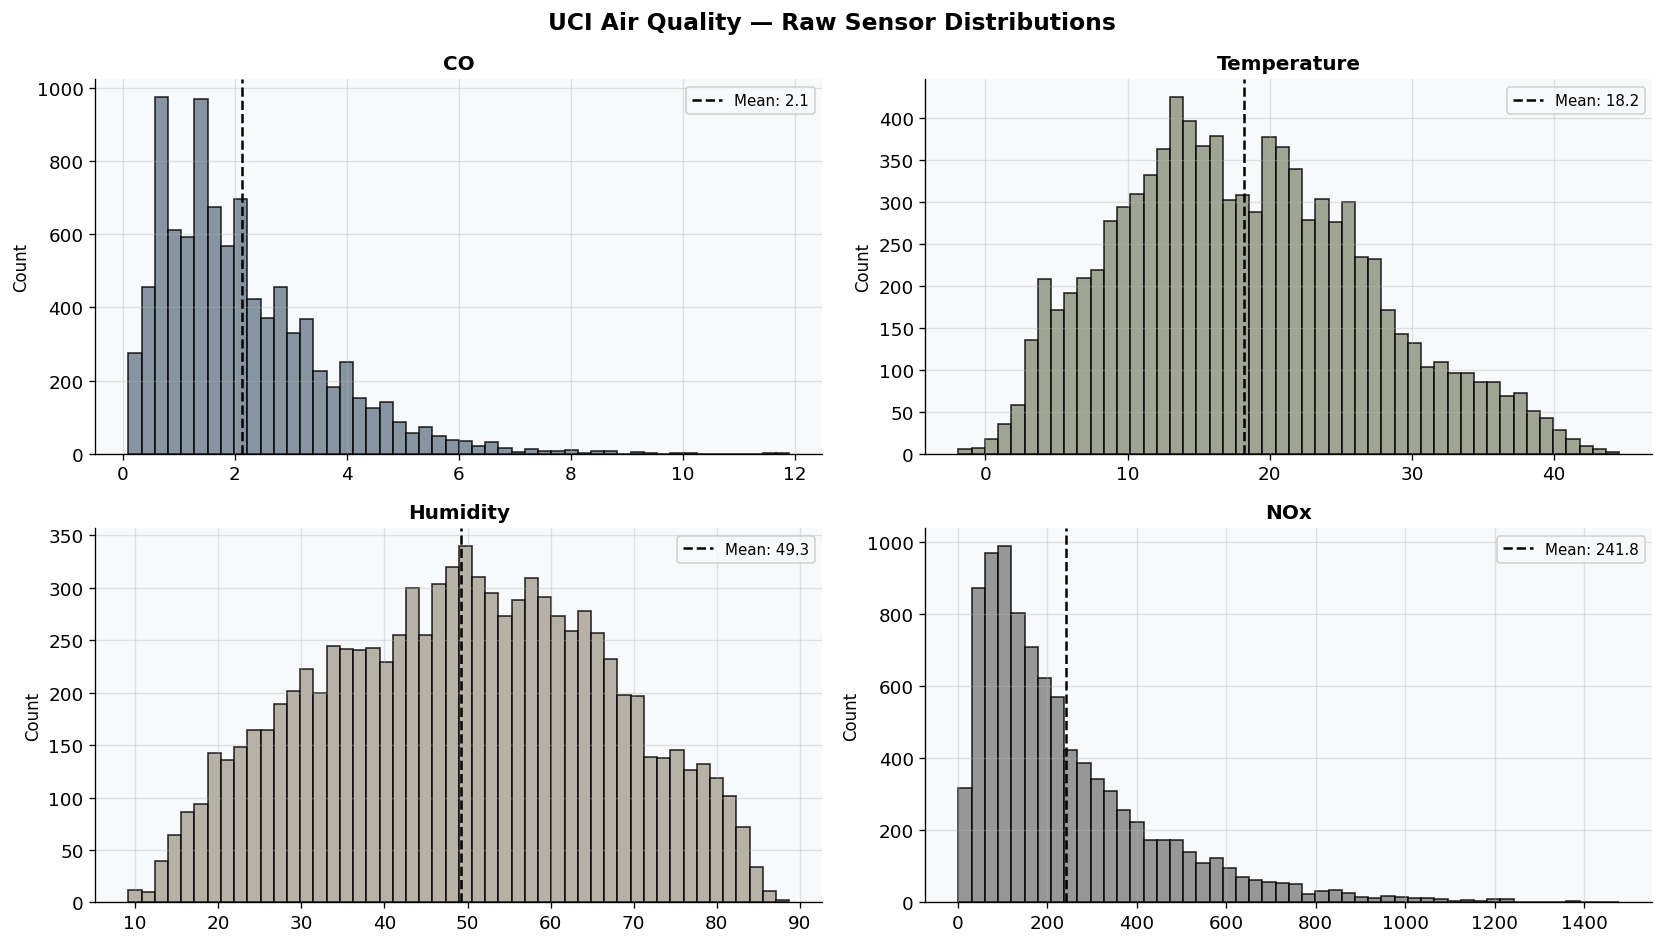

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('UCI Air Quality — Raw Sensor Distributions', fontsize=14, fontweight='bold')

colors = ['#6B7C8C', '#8A8F7A', '#A89F91', '#7F7F7F']

for ax, feat, color in zip(axes.flat, feature_cols, colors):
    ax.hist(df[feat].dropna(), bins=50, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(feat)
    ax.set_ylabel('Count')
    ax.axvline(df[feat].mean(), color='black', linestyle='--', label=f'Mean: {df[feat].mean():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

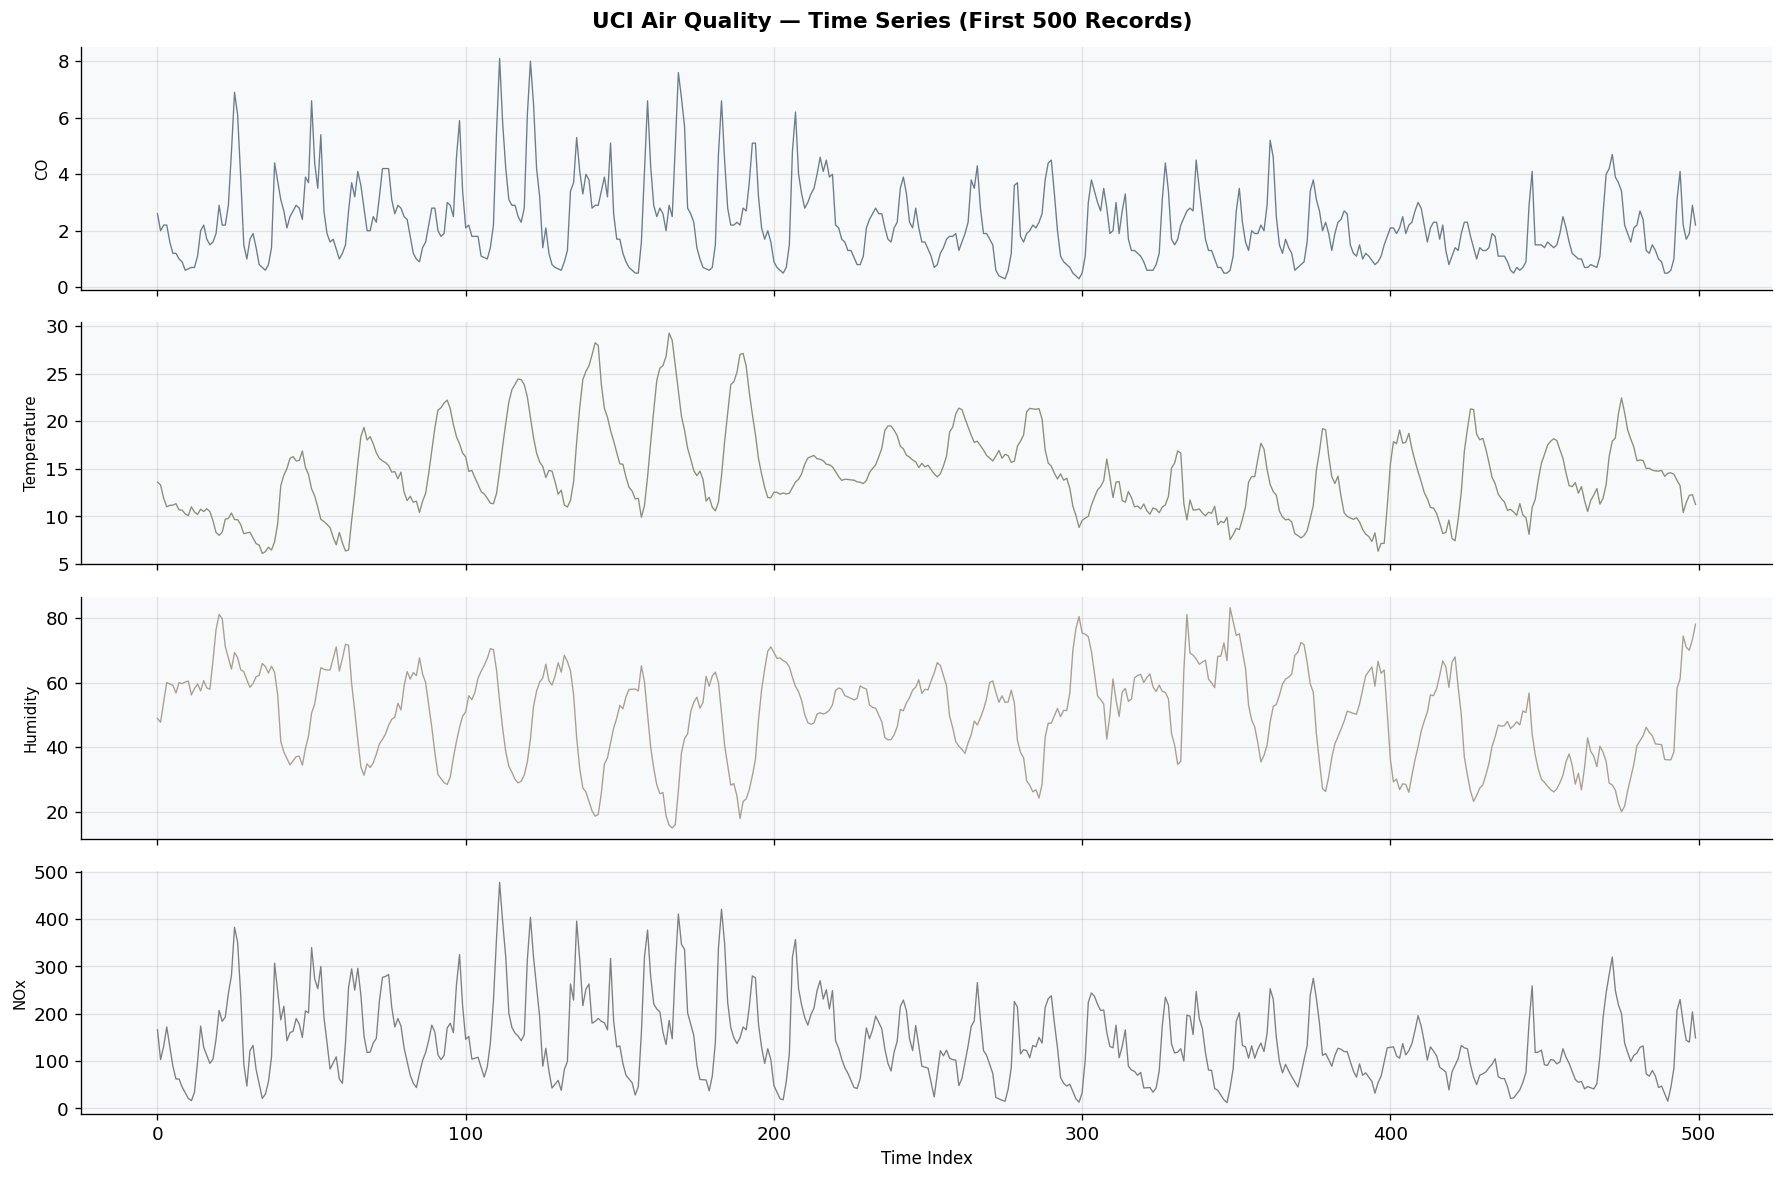

In [ ]:
fig, axes = plt.subplots(len(feature_cols), 1, figsize=(15, 10), sharex=True)
fig.suptitle('UCI Air Quality — Time Series (First 500 Records)', fontsize=13, fontweight='bold')

for ax, feat, color in zip(axes, feature_cols, colors):
    ax.plot(df[feat].iloc[:500].values, color=color, linewidth=0.8)
    ax.set_ylabel(feat, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Index')
plt.tight_layout()
plt.show()

In [ ]:
df['is_anomaly'] = 0

for feat, lo, hi in [
    ('CO', None, 0.85),
    ('NOx', None, 0.85),
    ('Temperature', 0.04, 0.96),
    ('Humidity', 0.04, 0.96),
]:
    if feat not in df.columns:
        continue
    if hi is not None:
        df.loc[df[feat] > df[feat].quantile(hi), 'is_anomaly'] = 1
    if lo is not None:
        df.loc[df[feat] < df[feat].quantile(lo), 'is_anomaly'] = 1

print(f'Total records: {len(df)}')
print(f'Anomalies labeled: {df["is_anomaly"].sum()} ({df["is_anomaly"].mean()*100:.1f}%)')
print(f'Normal records: {(df["is_anomaly"]==0).sum()}')

Total records: 9326
Anomalies labeled: 2974 (31.9%)
Normal records: 6352


In [ ]:
split_idx = int(len(df) * 0.70)

train_idx = np.arange(0, split_idx)
test_idx  = np.arange(split_idx, len(df))

# Labels
y_train = df['is_anomaly'].values[train_idx]
y_test  = df['is_anomaly'].values[test_idx]

# Raw feature matrix
print(f'Dataset size: {len(df):,} records')
print(f'Train set: {len(train_idx):,} records  '
      f'({y_train.mean()*100:.1f}% anomalies)')
print(f'Test set: {len(test_idx):,} records  '
      f'({y_test.mean()*100:.1f}% anomalies)')

Dataset size: 9,326 records
Train set: 6,528 records  (27.9% anomalies)
Test set: 2,798 records  (41.2% anomalies)


In [ ]:
class HuffmanNode:
    def __init__(self, symbol=None, freq=0, left=None, right=None):
        self.symbol = symbol
        self.freq   = freq
        self.left   = left
        self.right  = right
    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(data):
    freq = Counter(data)
    heap = [HuffmanNode(sym, f) for sym, f in freq.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        l = heapq.heappop(heap)
        r = heapq.heappop(heap)
        heapq.heappush(heap, HuffmanNode(freq=l.freq+r.freq, left=l, right=r))
    return heap[0]

def build_codebook(node, prefix='', cb=None):
    if cb is None: cb = {}
    if node.symbol is not None:
        cb[node.symbol] = prefix if prefix else '0'
    else:
        build_codebook(node.left,  prefix+'0', cb)
        build_codebook(node.right, prefix+'1', cb)
    return cb

def huffman_encode(data):
    tree = build_huffman_tree(data)
    codebook = build_codebook(tree)
    encoded = ''.join(codebook[s] for s in data)
    raw_bits = len(data) * 16
    enc_bits = len(encoded)
    ratio = raw_bits / enc_bits if enc_bits > 0 else 1
    bytes_saved = (raw_bits - enc_bits) / 8
    return encoded, codebook, {
        'raw_bits': raw_bits, 'encoded_bits': enc_bits,
        'compression_ratio': ratio, 'bytes_saved': bytes_saved,
        'n_symbols': len(codebook)
    }

def quantize(series, bins=100):
    return pd.cut(series, bins=bins, labels=False).fillna(0).astype(int).tolist()

# Apply Huffman to each feature
compression_results = {}

print(f"{'Feature':<15} | {'Raw bits':>10} | {'Encoded bits':>13} | {'Ratio':>7} | {'Bytes saved':>12}")
print('-' * 70)
for feat in feature_cols:
    q = quantize(df[feat])
    _, _, stats = huffman_encode(q)
    compression_results[feat] = stats
    print(f"{feat:<15} | {stats['raw_bits']:>10,} | {stats['encoded_bits']:>13,} | {stats['compression_ratio']:>7.3f} | {stats['bytes_saved']:>12,.0f}")

avg_ratio = np.mean([v['compression_ratio'] for v in compression_results.values()])
avg_encoded_bytes = int(np.mean([v['encoded_bits'] for v in compression_results.values()]) / 8)
raw_payload_bytes = int(np.mean([v['raw_bits'] for v in compression_results.values()]) / 8)

print(f'\nAverage compression ratio: {avg_ratio:.3f}x')
print(f'Avg compressed payload: {avg_encoded_bytes} bytes')
print(f'Avg raw payload: {raw_payload_bytes} bytes')

Feature         |   Raw bits |  Encoded bits |   Ratio |  Bytes saved
----------------------------------------------------------------------
CO              |    149,216 |        49,869 |   2.992 |       12,418
Temperature     |    149,216 |        58,327 |   2.558 |       11,361
Humidity        |    149,216 |        59,959 |   2.489 |       11,157
NOx             |    149,216 |        50,328 |   2.965 |       12,361

Average compression ratio: 2.751x
Avg compressed payload: 6827 bytes
Avg raw payload: 18652 bytes


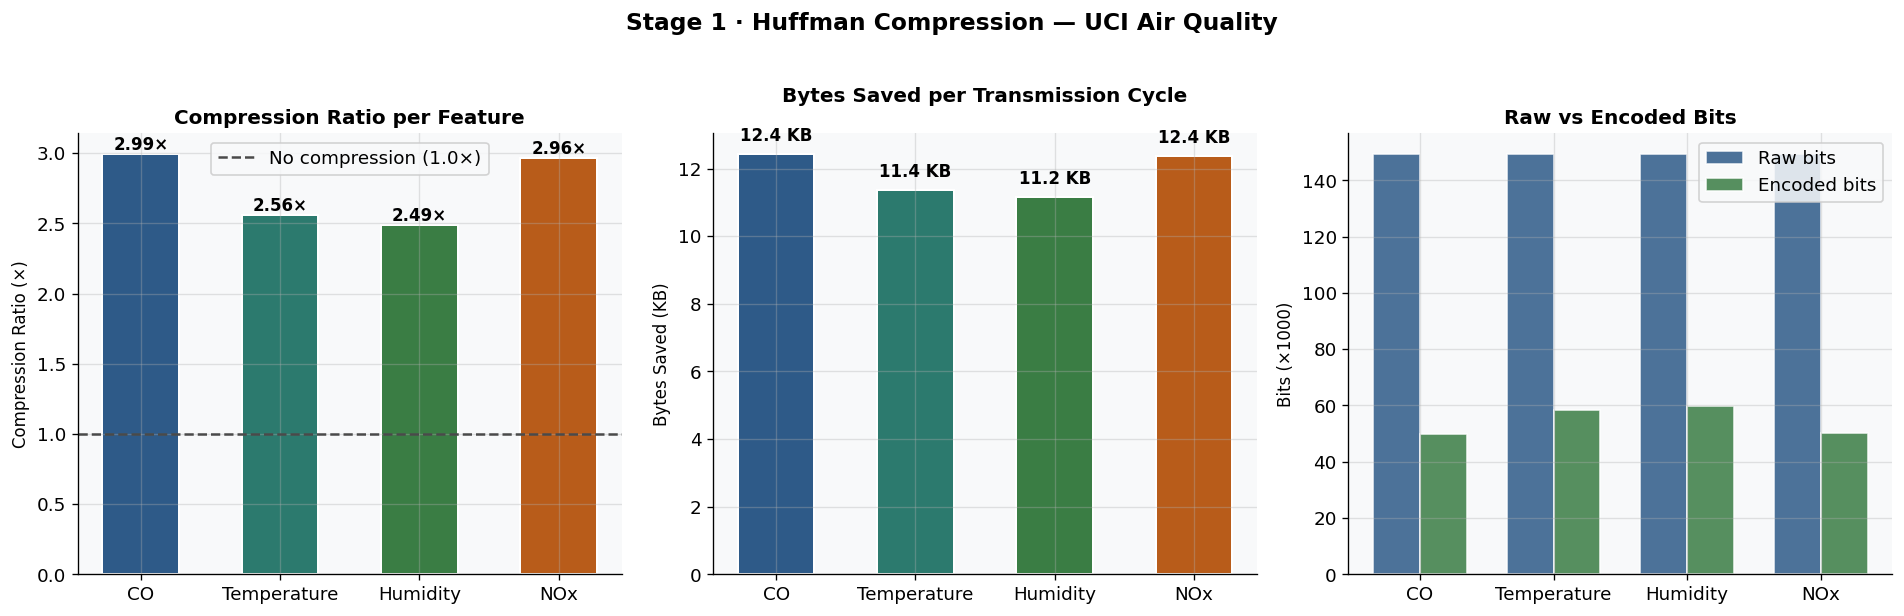


Average compression ratio: 2.751×  |  Avg payload: 6827 bytes → was 18652 bytes


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Stage 1 · Huffman Compression — UCI Air Quality', fontsize=14, fontweight='bold', y=1.02)

feat_names = list(compression_results.keys())
ratios     = [compression_results[f]['compression_ratio'] for f in feat_names]
saved_kb   = [compression_results[f]['bytes_saved'] / 1000 for f in feat_names]
raw_bits   = [compression_results[f]['raw_bits']     for f in feat_names]
enc_bits   = [compression_results[f]['encoded_bits'] for f in feat_names]

# (a) Compression ratio per feature
bars1 = axes[0].bar(feat_names, ratios, color=FEAT_COLORS, edgecolor='white', linewidth=1.2, width=0.55)
axes[0].axhline(1.0, color='#4A4A4A', linestyle='--', linewidth=1.5, label='No compression (1.0×)')
axes[0].set_title('Compression Ratio per Feature')
axes[0].set_ylabel('Compression Ratio (×)')
axes[0].legend()
for bar, r in zip(bars1, ratios):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03, f'{r:.2f}×',
                 ha='center', fontweight='bold', fontsize=10)

# (b) Bytes saved per cycle
bars2 = axes[1].bar(feat_names, saved_kb, color=FEAT_COLORS, edgecolor='white', linewidth=1.2, width=0.55)
axes[1].set_title('Bytes Saved per Transmission Cycle\n')
axes[1].set_ylabel('Bytes Saved (KB)')
for bar, s in zip(bars2, saved_kb):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4, f'{s:.1f} KB',
                 ha='center', fontweight='bold', fontsize=10)

# (c) Stacked raw vs encoded bits — now using muted blue and green
x = range(len(feat_names))
w = 0.35
axes[2].bar([xi - w/2 for xi in x], [b/1000 for b in raw_bits], width=w,
            label='Raw bits', color=PALETTE['raw'], edgecolor='white', alpha=0.85)
axes[2].bar([xi + w/2 for xi in x], [b/1000 for b in enc_bits], width=w,
            label='Encoded bits', color=PALETTE['encoded'], edgecolor='white', alpha=0.85)
axes[2].set_title('Raw vs Encoded Bits')
axes[2].set_ylabel('Bits (×1000)')
axes[2].set_xticks(list(x)); axes[2].set_xticklabels(feat_names)
axes[2].legend()

plt.tight_layout()
plt.savefig('stage1_compression.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\nAverage compression ratio: {avg_ratio:.3f}×  |  Avg payload: {avg_encoded_bytes} bytes → was {raw_payload_bytes} bytes')

In [ ]:
random.seed(42)
np.random.seed(42)

CONFIG = {
    'n_sensors': 50,
    'sim_duration': 500,
    'packet_loss_rates': [0.0, 0.05, 0.10, 0.20, 0.30],
    'pca_components': 12,
    'isolation_contamination': 0.10,
}
PROTOCOL_OVERHEAD = {'MQTT': 2, 'CoAP': 4, 'HTTP': 20}

In [ ]:
class NetworkStats:
    def __init__(self):
        self.sent = self.received = self.retransmissions = 0
        self.total_bytes = self.total_delay = 0.0
    @property
    def delivery_rate(self): return self.received/self.sent if self.sent else 0
    @property
    def avg_delay(self): return self.total_delay/self.received if self.received else 0


def mqtt_sensor(env, sid, payload_bytes, loss, stats):
    header = PROTOCOL_OVERHEAD['MQTT']
    while True:
        yield env.timeout(1)
        stats.sent += 1
        tb = payload_bytes + header
        if random.random() < loss:
            stats.retransmissions += 1
            yield env.timeout(0.5)
            tb += payload_bytes + header
            if random.random() >= loss:
                stats.received += 1
                stats.total_bytes += tb
                stats.total_delay += 1.5
        else:
            stats.received += 1
            stats.total_bytes += tb
            stats.total_delay += 1.0
        if env.now >= CONFIG['sim_duration']: break


def coap_sensor(env, sid, payload_bytes, loss, stats):
    header = PROTOCOL_OVERHEAD['CoAP']
    while True:
        yield env.timeout(1)
        stats.sent += 1
        tb = payload_bytes + header
        if random.random() < loss:
            stats.retransmissions += 1
            yield env.timeout(2.0)
            tb += payload_bytes + header
            if random.random() >= loss:
                stats.received += 1
                stats.total_bytes += tb
                stats.total_delay += 3.0
        else:
            stats.received += 1
            stats.total_bytes += tb
            stats.total_delay += 0.8
        if env.now >= CONFIG['sim_duration']: break


def run_simulation(protocol, packet_loss, payload_bytes, n_sensors=10):
    env   = simpy.Environment()
    stats = NetworkStats()
    fn = mqtt_sensor if protocol == 'MQTT' else coap_sensor
    for sid in range(n_sensors):
        env.process(fn(env, sid, payload_bytes, packet_loss, stats))
    env.run(until=CONFIG['sim_duration'])
    return stats


print('Running network simulations across protocols and loss rates...')
sim_results = []
for loss in CONFIG['packet_loss_rates']:
    for protocol in ['MQTT', 'CoAP']:
        for comp_label, payload in [('Compressed', avg_encoded_bytes), ('Uncompressed', raw_payload_bytes)]:
            stats = run_simulation(protocol, loss, payload, CONFIG['n_sensors'])
            sim_results.append({
                'protocol': protocol,
                'packet_loss': loss,
                'compression': comp_label,
                'delivery_rate': stats.delivery_rate,
                'avg_delay': stats.avg_delay,
                'retransmissions': stats.retransmissions,
                'total_bytes': stats.total_bytes,
            })

sim_df = pd.DataFrame(sim_results)
print('Simulation complete.\n')
print(sim_df[sim_df['compression']=='Compressed'][
    ['protocol','packet_loss','delivery_rate','avg_delay','retransmissions']
].to_string(index=False))

Running network simulations across protocols and loss rates...
Simulation complete.

protocol  packet_loss  delivery_rate  avg_delay  retransmissions
    MQTT         0.00       1.000000   1.000000                0
    CoAP         0.00       1.000000   0.800000                0
    MQTT         0.05       0.997579   1.023471             1200
    CoAP         0.05       0.997125   0.908331             1175
    MQTT         0.10       0.989786   1.044696             2348
    CoAP         0.10       0.991377   0.998376             2046
    MQTT         0.20       0.959645   1.084103             4575
    CoAP         0.20       0.958256   1.162379             3562
    MQTT         0.30       0.910047   1.116552             6552
    CoAP         0.30       0.910871   1.294263             4621


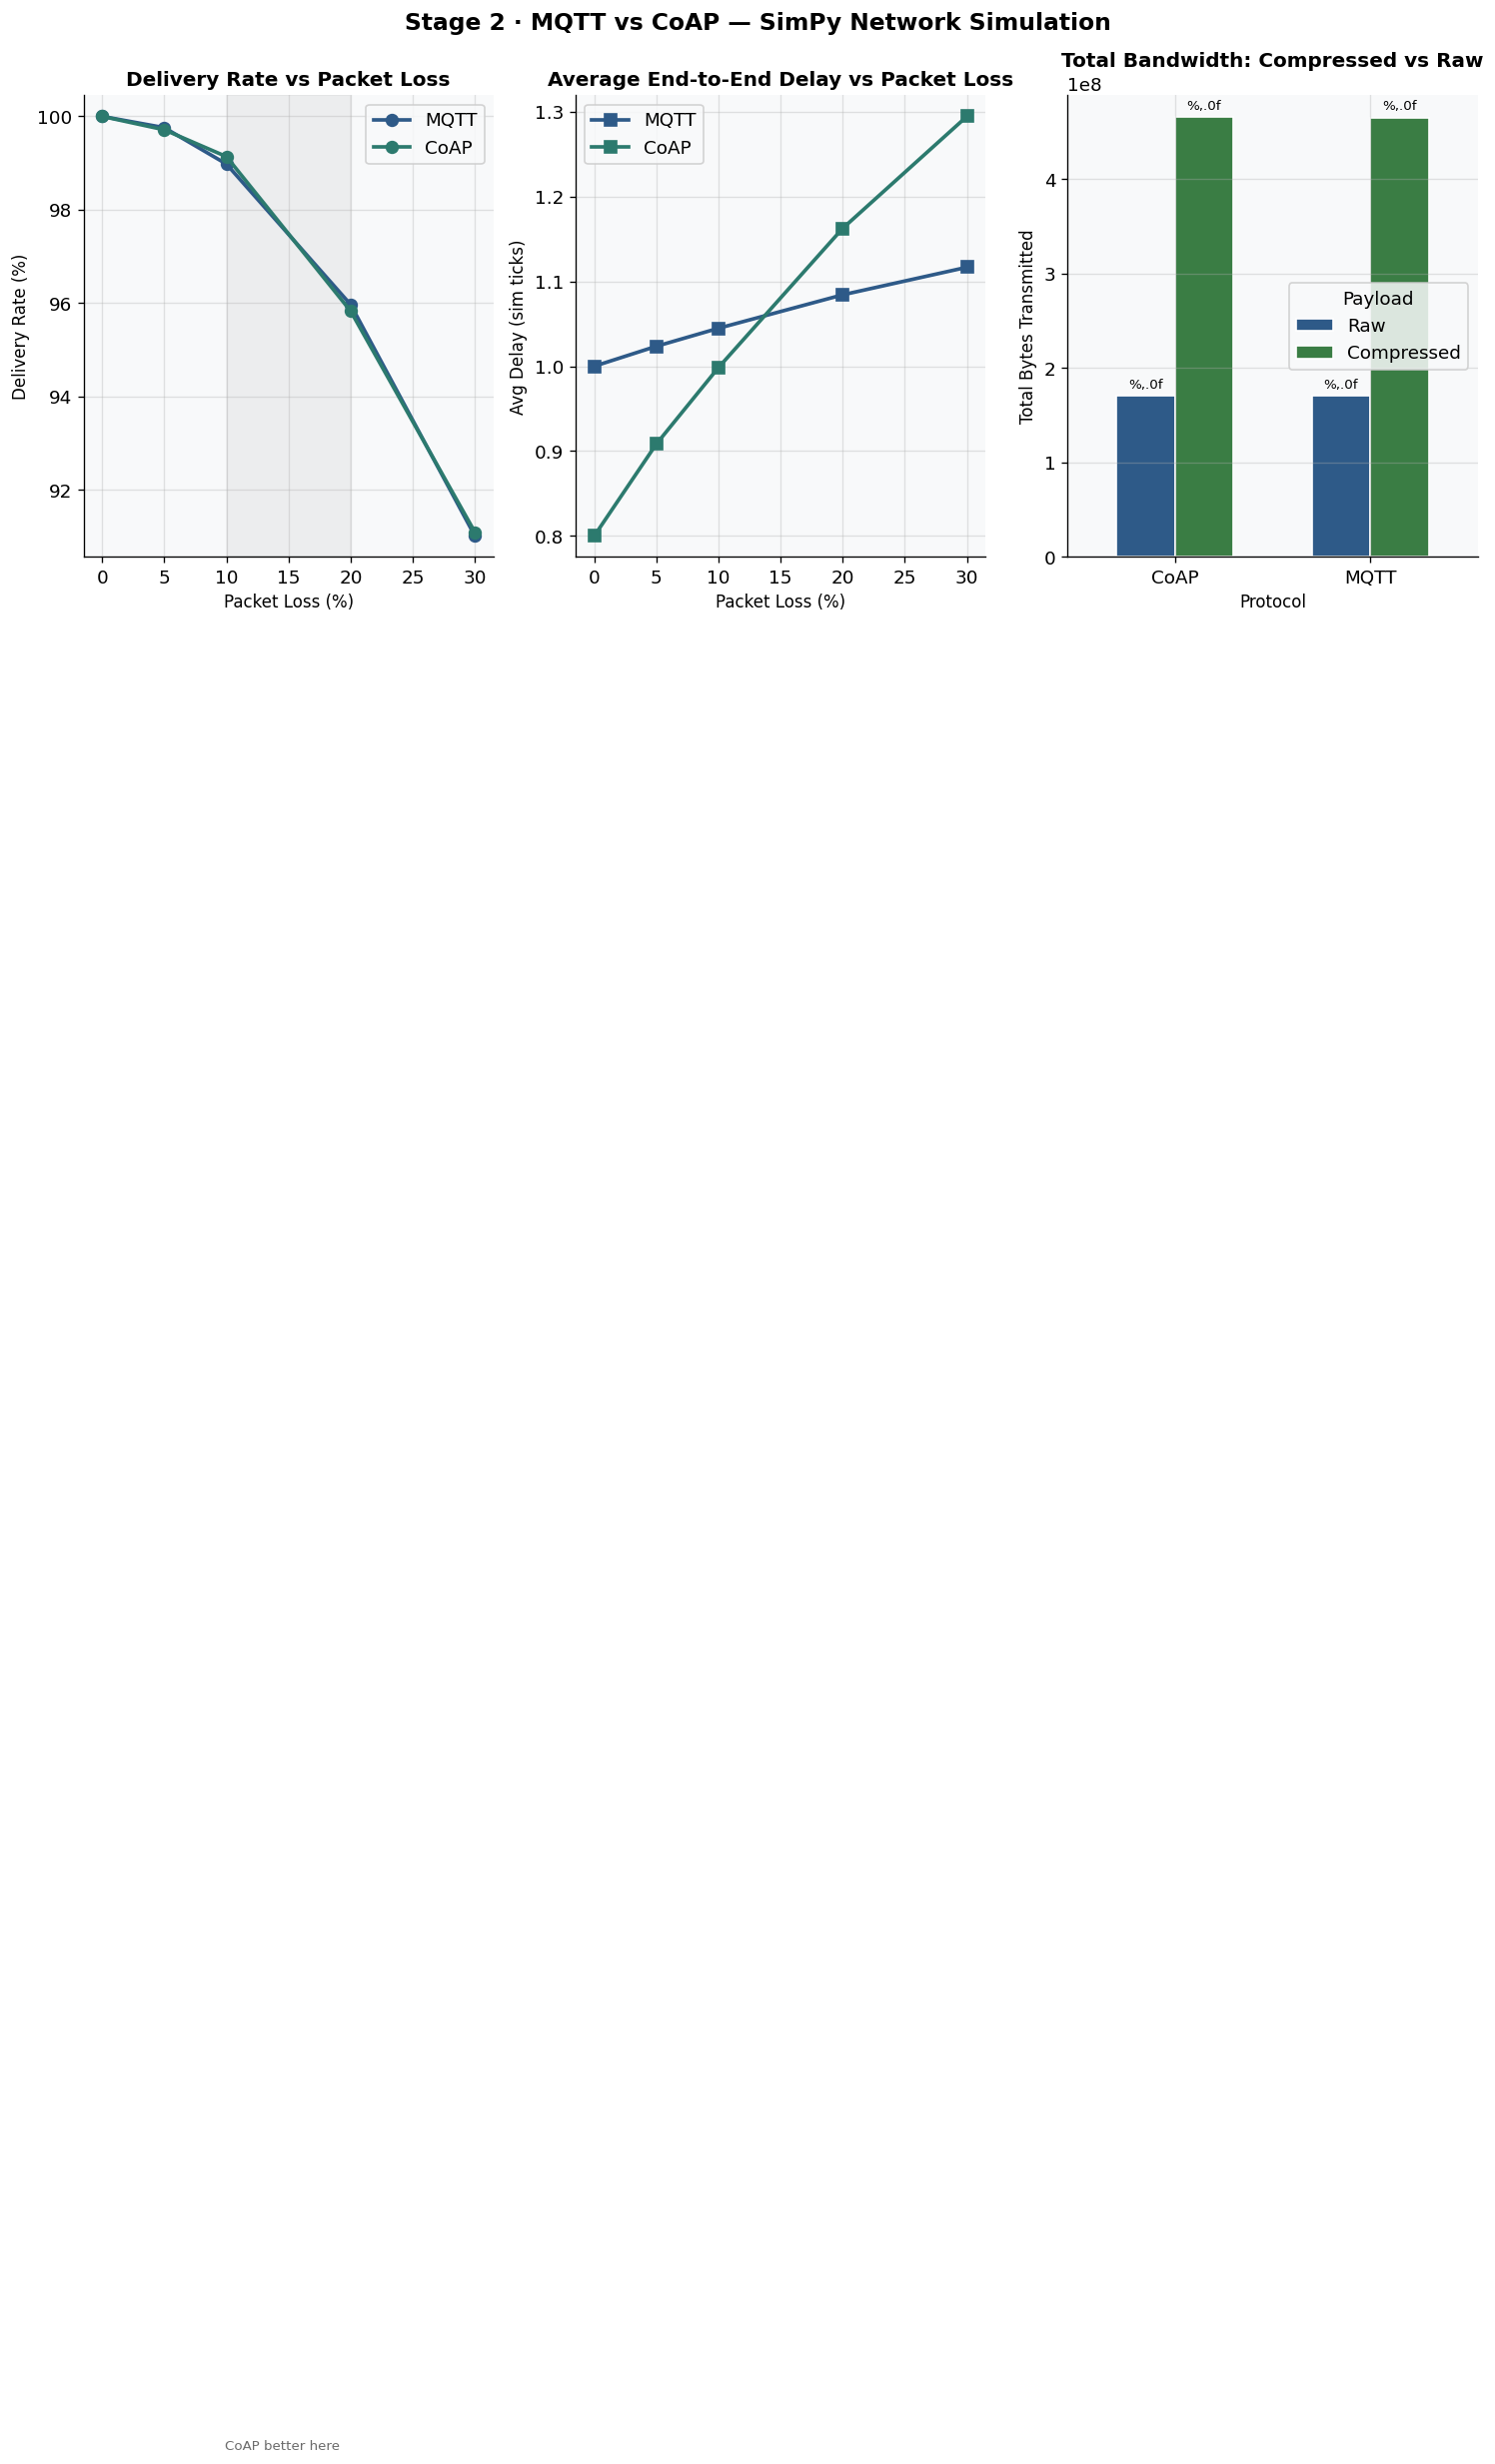

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Stage 2 · MQTT vs CoAP — SimPy Network Simulation\n\n', fontsize=14, fontweight='bold', y=1.02)

comp_sim = sim_df[sim_df['compression'] == 'Compressed']

# (a) Delivery rate vs packet loss
for proto in ['MQTT', 'CoAP']:
    sub = comp_sim[comp_sim['protocol'] == proto]
    axes[0].plot(sub['packet_loss']*100, sub['delivery_rate']*100,
                 marker='o', label=proto, color=PROTO_COLORS[proto], linewidth=2.2, markersize=7)
axes[0].set_title('Delivery Rate vs Packet Loss')
axes[0].set_xlabel('Packet Loss (%)')
axes[0].set_ylabel('Delivery Rate (%)')
axes[0].legend()
# Annotating crossover region
axes[0].axvspan(10, 20, alpha=0.08, color=ACADEMIC_COLORS['gray'], label='_nolegend_')
axes[0].text(14.5, 50, 'CoAP better here', fontsize=8, color=ACADEMIC_COLORS['gray'], ha='center')

# (b) Average delay vs packet loss
for proto in ['MQTT', 'CoAP']:
    sub = comp_sim[comp_sim['protocol'] == proto]
    axes[1].plot(sub['packet_loss']*100, sub['avg_delay'],
                 marker='s', label=proto, color=PROTO_COLORS[proto], linewidth=2.2, markersize=7)
axes[1].set_title('Average End-to-End Delay vs Packet Loss')
axes[1].set_xlabel('Packet Loss (%)')
axes[1].set_ylabel('Avg Delay (sim ticks)')
axes[1].legend()

# (c) Bandwidth: compressed vs uncompressed at 0% loss
loss0 = sim_df[sim_df['packet_loss'] == 0.0]
pivot_bw = loss0.groupby(['protocol', 'compression'])['total_bytes'].mean().unstack()
pivot_bw.plot(kind='bar', ax=axes[2], color=[PALETTE['raw'], PALETTE['encoded']],
              edgecolor='white', linewidth=1, width=0.6)
axes[2].set_title('\nTotal Bandwidth: Compressed vs Raw')
axes[2].set_xlabel('Protocol')
axes[2].set_ylabel('Total Bytes Transmitted')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Payload', labels=['Raw', 'Compressed'])
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%,.0f', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('stage2_network.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
X_raw = df[feature_cols_extended].values
y = df['is_anomaly'].values

# Splitting into train/test using the temporal indices defined above
X_raw_train, X_raw_test = X_raw[train_idx], X_raw[test_idx]

# Step 1: VarianceThreshold — fit on train only
vt = VarianceThreshold(threshold=1e-6)
X_vt_train = vt.fit_transform(X_raw_train)
X_vt_test  = vt.transform(X_raw_test)
print(f'Features after variance threshold: {X_vt_train.shape[1]} (was {X_raw_train.shape[1]})')

# Step 2: RobustScaler — fit on train only
scaler = RobustScaler()
X_scaled_train = scaler.fit_transform(X_vt_train)
X_scaled_test = scaler.transform(X_vt_test)

# Keeping a full-dataset scaled version only for PCA visualisation
X_scaled_full = scaler.transform(vt.transform(X_raw))

# Step 3: PCA — fit on train only
n_pca = min(CONFIG['pca_components'], X_scaled_train.shape[1])
pca = PCA(n_components=n_pca)
X_pca_train = pca.fit_transform(X_scaled_train)
X_pca_test = pca.transform(X_scaled_test)
X_pca_full = pca.transform(X_scaled_full)

explained = pca.explained_variance_ratio_
print('PCA Explained Variance (fit on train):')
for i, ev in enumerate(explained):
    print(f'PC{i+1}: {ev*100:.2f}%')
print(f'Total: {sum(explained)*100:.2f}%')

# Contamination = anomaly rate in train set only
actual_contamination = float(y_train.mean())
print(f'\nTrain anomaly rate (used as contamination): {actual_contamination*100:.1f}%')
print(f'Test  anomaly rate (held-out): {y_test.mean()*100:.1f}%')


Features after variance threshold: 136 (was 138)
PCA Explained Variance (fit on train):
PC1: 27.38%
PC2: 12.21%
PC3: 11.24%
PC4: 10.47%
PC5: 7.20%
PC6: 4.01%
PC7: 3.40%
PC8: 3.17%
PC9: 2.67%
PC10: 2.37%
PC11: 1.91%
PC12: 1.72%
Total: 87.75%

Train anomaly rate (used as contamination): 27.9%
Test  anomaly rate (held-out): 41.2%


In [ ]:
print('Sweeping contamination values on TRAIN set...')
best_f1_sw, best_cont = 0.0, actual_contamination
for _c in np.arange(0.03, 0.40, 0.005):
    _c = round(float(_c), 3)
    _p = (IsolationForest(contamination=_c, n_estimators=600, random_state=42)
          .fit_predict(X_scaled_train) == -1).astype(int)
    tp = np.sum((y_train==1)&(_p==1)); fp = np.sum((y_train==0)&(_p==1)); fn = np.sum((y_train==1)&(_p==0))
    pr = tp/(tp+fp+1e-9); rc = tp/(tp+fn+1e-9)
    f1 = 2*pr*rc/(pr+rc+1e-9)
    if f1 > best_f1_sw:
        best_f1_sw, best_cont = f1, _c
print(f'  Best contamination (train): {best_cont:.3f}  →  train F1 = {best_f1_sw:.3f}')


Sweeping contamination values on TRAIN set...
  Best contamination (train): 0.305  →  train F1 = 0.697


In [ ]:
pca_std = np.std(X_pca_train, axis=0) + 1e-9
pca_dist_train = np.sqrt(np.sum((X_pca_train / pca_std)**2, axis=1))
pca_dist_test = np.sqrt(np.sum((X_pca_test  / pca_std)**2, axis=1))
thr_dist = np.percentile(pca_dist_train, (1 - actual_contamination)*100)
iqr_pred = (pca_dist_test > thr_dist).astype(int)

iso = IsolationForest(contamination=best_cont, n_estimators=600,
                      max_samples='auto', max_features=0.8, random_state=42)
iso.fit(X_scaled_train)
iso_pred = (iso.predict(X_scaled_test) == -1).astype(int)
iso_scores = -iso.score_samples(X_scaled_test)

lof = LocalOutlierFactor(n_neighbors=30, contamination=best_cont, novelty=True)
lof.fit(X_scaled_train)
lof_pred = (lof.predict(X_scaled_test) == -1).astype(int)
lof_scores = -lof.score_samples(X_scaled_test)

ocsvm = OneClassSVM(nu=best_cont, kernel='rbf', gamma='scale')
ocsvm.fit(X_scaled_train)
ocsvm_pred = (ocsvm.predict(X_scaled_test) == -1).astype(int)
ocsvm_scores = -ocsvm.decision_function(X_scaled_test)

iso_pca = IsolationForest(contamination=best_cont, n_estimators=400,
                          max_features=0.9, random_state=123)
iso_pca.fit(X_pca_train)
iso_pca_pred   = (iso_pca.predict(X_pca_test) == -1).astype(int)
iso_pca_scores = -iso_pca.score_samples(X_pca_test)

print('All base detectors fitted on TRAIN, predictions made on TEST.')
print(f'Test set size: {len(y_test):,} records')


All base detectors fitted on TRAIN, predictions made on TEST.
Test set size: 2,798 records


In [ ]:
def minmax(v):
    mn, mx = v.min(), v.max()
    return (v - mn) / (mx - mn + 1e-9)

def detector_f1(y_true, scores, cont):
    thr  = np.percentile(scores, (1-cont)*100)
    pred = (scores >= thr).astype(int)
    tp = np.sum((y_true==1)&(pred==1))
    fp = np.sum((y_true==0)&(pred==1))
    fn = np.sum((y_true==1)&(pred==0))
    p  = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
    return 2*p*r/(p+r+1e-9)

iso_scores_train = minmax(-iso.score_samples(X_scaled_train))
lof_scores_train = minmax(-lof.score_samples(X_scaled_train))
ocsvm_scores_train = minmax(-ocsvm.decision_function(X_scaled_train))
iso_pca_scores_train = minmax(-iso_pca.score_samples(X_pca_train))
iqr_scores_train = minmax(pca_dist_train)

w_iso = detector_f1(y_train, iso_scores_train,     best_cont)
w_lof = detector_f1(y_train, lof_scores_train,     best_cont)
w_ocsvm = detector_f1(y_train, ocsvm_scores_train,   best_cont)
w_iso_pca = detector_f1(y_train, iso_pca_scores_train, best_cont)
w_iqr = detector_f1(y_train, iqr_scores_train,     best_cont)
w_total = w_iso + w_lof + w_ocsvm + w_iso_pca + w_iqr + 1e-9

print(f'Detector weights (from TRAIN) — IF:{w_iso:.3f} LOF:{w_lof:.3f}  '
      f'OCSVM:{w_ocsvm:.3f}  IF_PCA:{w_iso_pca:.3f} IQR:{w_iqr:.3f}')

sc_iso = minmax(iso_scores)
sc_lof = minmax(lof_scores)
sc_ocsvm = minmax(ocsvm_scores)
sc_iso_pca = minmax(iso_pca_scores)
sc_iqr = minmax(pca_dist_test)

stack_score = (
    w_iso * sc_iso +
    w_lof * sc_lof +
    w_ocsvm * sc_ocsvm +
    w_iso_pca * sc_iso_pca +
    w_iqr * sc_iqr
) / w_total


Detector weights (from TRAIN) — IF:0.674 LOF:0.387  OCSVM:0.604  IF_PCA:0.557 IQR:0.561


In [ ]:
train_stack = (
    w_iso * iso_scores_train +
    w_lof * lof_scores_train +
    w_ocsvm * ocsvm_scores_train +
    w_iso_pca * iso_pca_scores_train +
    w_iqr * iqr_scores_train
) / w_total

precisions_tr, recalls_tr, pr_thr_tr = precision_recall_curve(y_train, train_stack)
f1_curve_tr = 2*precisions_tr*recalls_tr/(precisions_tr+recalls_tr+1e-9)
best_thr_pr = pr_thr_tr[np.argmax(f1_curve_tr[:-1])]

best_thr_pct, best_f1_pct = best_thr_pr, 0.0
for pct in np.arange(0.55, 0.99, 0.001):
    thr_try  = np.percentile(train_stack, pct*100)
    pred_try = (train_stack >= thr_try).astype(int)
    tp = np.sum((y_train==1)&(pred_try==1))
    fp = np.sum((y_train==0)&(pred_try==1))
    fn = np.sum((y_train==1)&(pred_try==0))
    p  = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
    f1 = 2*p*r/(p+r+1e-9)
    if f1 > best_f1_pct:
        best_f1_pct, best_thr_pct = f1, thr_try

best_thr = best_thr_pr if f1_curve_tr[np.argmax(f1_curve_tr[:-1])] >= best_f1_pct else best_thr_pct
ensemble_pred = (stack_score >= best_thr).astype(int)
print(f'Threshold selected on TRAIN, applied to TEST.')
print(f'TEST ensemble predictions: {ensemble_pred.sum()} flagged as anomalies out of {len(ensemble_pred)}')


Threshold selected on TRAIN, applied to TEST.
TEST ensemble predictions: 2142 flagged as anomalies out of 2798


In [ ]:
try:
    import xgboost as xgb

    high_thr     = np.percentile(train_stack, 92)
    low_thr      = np.percentile(train_stack, 8)
    pseudo_mask  = (train_stack >= high_thr) | (train_stack <= low_thr)
    pseudo_labels = (train_stack >= high_thr).astype(int)

    X_pseudo = X_pca_train[pseudo_mask]
    y_pseudo = pseudo_labels[pseudo_mask]

    print(f'Pseudo-label set (TRAIN only): {pseudo_mask.sum()} samples  '
          f'(anomaly: {y_pseudo.sum()}, normal: {(y_pseudo==0).sum()})')

    scale_pos = max((y_pseudo==0).sum() / (y_pseudo==1).sum(), 1.0)

    xgb_model = xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0
    )
    xgb_model.fit(X_pseudo, y_pseudo)

    xgb_scores = xgb_model.predict_proba(X_pca_test)[:, 1]

    alpha = 0.40
    train_blended = (1-alpha) * train_stack + alpha * xgb_model.predict_proba(X_pca_train)[:, 1]
    test_blended  = (1-alpha) * stack_score  + alpha * xgb_scores

    p2, r2, thr2 = precision_recall_curve(y_train, train_blended)
    f2 = 2*p2*r2/(p2+r2+1e-9)
    best_thr_blend = thr2[np.argmax(f2[:-1])]
    for pct in np.arange(0.55, 0.99, 0.001):
        t  = np.percentile(train_blended, pct*100)
        pr = (train_blended >= t).astype(int)
        tp = np.sum((y_train==1)&(pr==1)); fp = np.sum((y_train==0)&(pr==1)); fn = np.sum((y_train==1)&(pr==0))
        p_ = tp/(tp+fp+1e-9); r_ = tp/(tp+fn+1e-9)
        f_ = 2*p_*r_/(p_+r_+1e-9)
        if f_ > f2[np.argmax(f2[:-1])]:
            best_thr_blend = t

    xgb_ensemble_pred = (test_blended >= best_thr_blend).astype(int)
    blended_score = test_blended
    best_f1_blend = 0.0
    xgb_available = True
    print('XGBoost trained on TRAIN pseudo-labels, evaluated on TEST.')

except Exception as e:
    print(f'XGBoost not available or failed: {e}')
    xgb_available = False
    xgb_ensemble_pred = ensemble_pred
    best_f1_blend = 0.0
    blended_score = stack_score
    best_thr_blend    = best_thr


Pseudo-label set (TRAIN only): 1046 samples  (anomaly: 523, normal: 523)
XGBoost trained on TRAIN pseudo-labels, evaluated on TEST.


In [ ]:
def evaluate(y_true, y_pred, name):
    tp = np.sum((y_true==1)&(y_pred==1))
    fp = np.sum((y_true==0)&(y_pred==1))
    fn = np.sum((y_true==1)&(y_pred==0))
    p  = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
    f1 = 2*p*r/(p+r+1e-9)
    print(f'{name}: P={p:.3f}  R={r:.3f}  F1={f1:.3f}  TP={tp}  FP={fp}  FN={fn}')
    return {'name': name, 'precision': p, 'recall': r, 'f1': f1}

print('--- Anomaly Detection Results (TEST SET — held-out 30%) ---')
iqr_m = evaluate(y_test, iqr_pred, '\nPCA Mahalanobis')
iso_m = evaluate(y_test, iso_pred, '\nIsolation Forest (tuned)')
lof_m = evaluate(y_test, lof_pred, '\nLOF (n=30)')
osv_m = evaluate(y_test, ocsvm_pred, '\nOne-Class SVM')
ens_m = evaluate(y_test, ensemble_pred, '\nWtd Ensemble (5 detect.)')
if xgb_available:
    xgb_m = evaluate(y_test, xgb_ensemble_pred, '\nXGB Semi-Supervised Blend')
else:
    xgb_m = ens_m

all_m = [iqr_m, iso_m, lof_m, osv_m, ens_m, xgb_m]
all_p = [iqr_pred, iso_pred, lof_pred, ocsvm_pred, ensemble_pred, xgb_ensemble_pred]
best_i = max(range(len(all_m)), key=lambda i: all_m[i]['f1'])
iso_pred_final = all_p[best_i]
best_model_f1 = all_m[best_i]['f1']
if xgb_available:
    best_f1_blend = xgb_m['f1']

X_pca = X_pca_full
y_viz = y

print(f'\nBest model: {all_m[best_i]["name"].strip()} (Test F1={best_model_f1:.3f})')

--- Anomaly Detection Results (TEST SET — held-out 30%) ---

PCA Mahalanobis: P=0.519  R=0.857  F1=0.647  TP=987  FP=913  FN=165

Isolation Forest (tuned): P=0.481  R=0.974  F1=0.644  TP=1122  FP=1213  FN=30

LOF (n=30): P=0.434  R=0.859  F1=0.576  TP=989  FP=1292  FN=163

One-Class SVM: P=0.584  R=0.897  F1=0.707  TP=1033  FP=737  FN=119

Wtd Ensemble (5 detect.): P=0.512  R=0.951  F1=0.665  TP=1096  FP=1046  FN=56

XGB Semi-Supervised Blend: P=0.534  R=0.866  F1=0.660  TP=998  FP=872  FN=154

Best model: One-Class SVM (Test F1=0.707)


In [ ]:
warnings.filterwarnings('ignore')

def quick_if_f1(X_tr, X_te, y_te, cont):
    clf = IsolationForest(contamination=cont, n_estimators=300, random_state=42)
    clf.fit(X_tr)
    scores = -clf.score_samples(X_te)
    tr_scores = -clf.score_samples(X_tr)
    best_t, best_f = np.percentile(tr_scores, (1-cont)*100), 0.0
    for pct in np.arange(0.55, 0.99, 0.01):
        t   = np.percentile(tr_scores, pct*100)
        pr  = (tr_scores >= t).astype(int)
        tp_ = np.sum((y_train==1)&(pr==1)); fp_ = np.sum((y_train==0)&(pr==1)); fn_ = np.sum((y_train==1)&(pr==0))
        p_  = tp_/(tp_+fp_+1e-9); r_ = tp_/(tp_+fn_+1e-9)
        f_  = 2*p_*r_/(p_+r_+1e-9)
        if f_ > best_f: best_f, best_t = f_, t
    pred = (scores >= best_t).astype(int)
    tp = np.sum((y_te==1)&(pred==1)); fp = np.sum((y_te==0)&(pred==1)); fn = np.sum((y_te==1)&(pred==0))
    p  = tp/(tp+fp+1e-9); r  = tp/(tp+fn+1e-9)
    return 2*p*r/(p+r+1e-9)

print('Running ablation study (each row = full pipeline minus one component)...')
print()

ablation_results = []

# Full pipeline (reference)
full_f1 = best_model_f1
ablation_results.append(('Full pipeline (reference)', full_f1))

# No feature engineering — only 4 raw features
X_raw4_train = scaler.fit_transform(vt.fit_transform(df[feature_cols].values[train_idx]))
X_raw4_test  = scaler.transform(vt.transform(df[feature_cols].values[test_idx]))
f1_no_eng = quick_if_f1(X_raw4_train, X_raw4_test, y_test, best_cont)
ablation_results.append(('No feature engineering (4 raw features)', f1_no_eng))

# No PCA — use scaled features directly (full feature set, no dimensionality reduction)
f1_no_pca = quick_if_f1(X_scaled_train, X_scaled_test, y_test, best_cont)
ablation_results.append(('No PCA (full scaled features, single IF)', f1_no_pca))

# Single detector (IsolationForest only, no ensemble)
iso_only = IsolationForest(contamination=best_cont, n_estimators=600, random_state=42)
iso_only.fit(X_pca_train)
iso_only_scores = -iso_only.score_samples(X_pca_test)
tr_s = -iso_only.score_samples(X_pca_train)
best_t_iso = np.percentile(tr_s, (1-best_cont)*100)
iso_only_pred = (iso_only_scores >= best_t_iso).astype(int)
tp = np.sum((y_test==1)&(iso_only_pred==1)); fp = np.sum((y_test==0)&(iso_only_pred==1)); fn = np.sum((y_test==1)&(iso_only_pred==0))
p = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
f1_single = 2*p*r/(p+r+1e-9)
ablation_results.append(('Single detector only (IF, no ensemble)', f1_single))

# No XGBoost blend
f1_no_xgb = ens_m['f1']
ablation_results.append(('No XGBoost blend (ensemble only)', f1_no_xgb))

# No compression — bandwidth impact only (F1 unaffected by compression itself)
ablation_results.append(('No Huffman compression (bandwidth only)', full_f1))

print(f'{"Configuration":<45} {"Test F1":>8}  {"vs Full":>8}')
print('  ' + '-'*65)
for name, f1 in ablation_results:
    delta = f1 - full_f1
    marker = ' reference' if name.startswith('Full') else f' ({delta:+.3f})'
    print(f'{name:<45} {f1:>8.3f}{marker}')

print()
print('Ablation complete. Each row was evaluated on the same held-out TEST set.')


Running ablation study (each row = full pipeline minus one component)...

Configuration                                  Test F1   vs Full
  -----------------------------------------------------------------
Full pipeline (reference)                        0.707 reference
No feature engineering (4 raw features)          0.679 (-0.028)
No PCA (full scaled features, single IF)         0.646 (-0.061)
Single detector only (IF, no ensemble)           0.656 (-0.052)
No XGBoost blend (ensemble only)                 0.665 (-0.042)
No Huffman compression (bandwidth only)          0.707 (+0.000)

Ablation complete. Each row was evaluated on the same held-out TEST set.


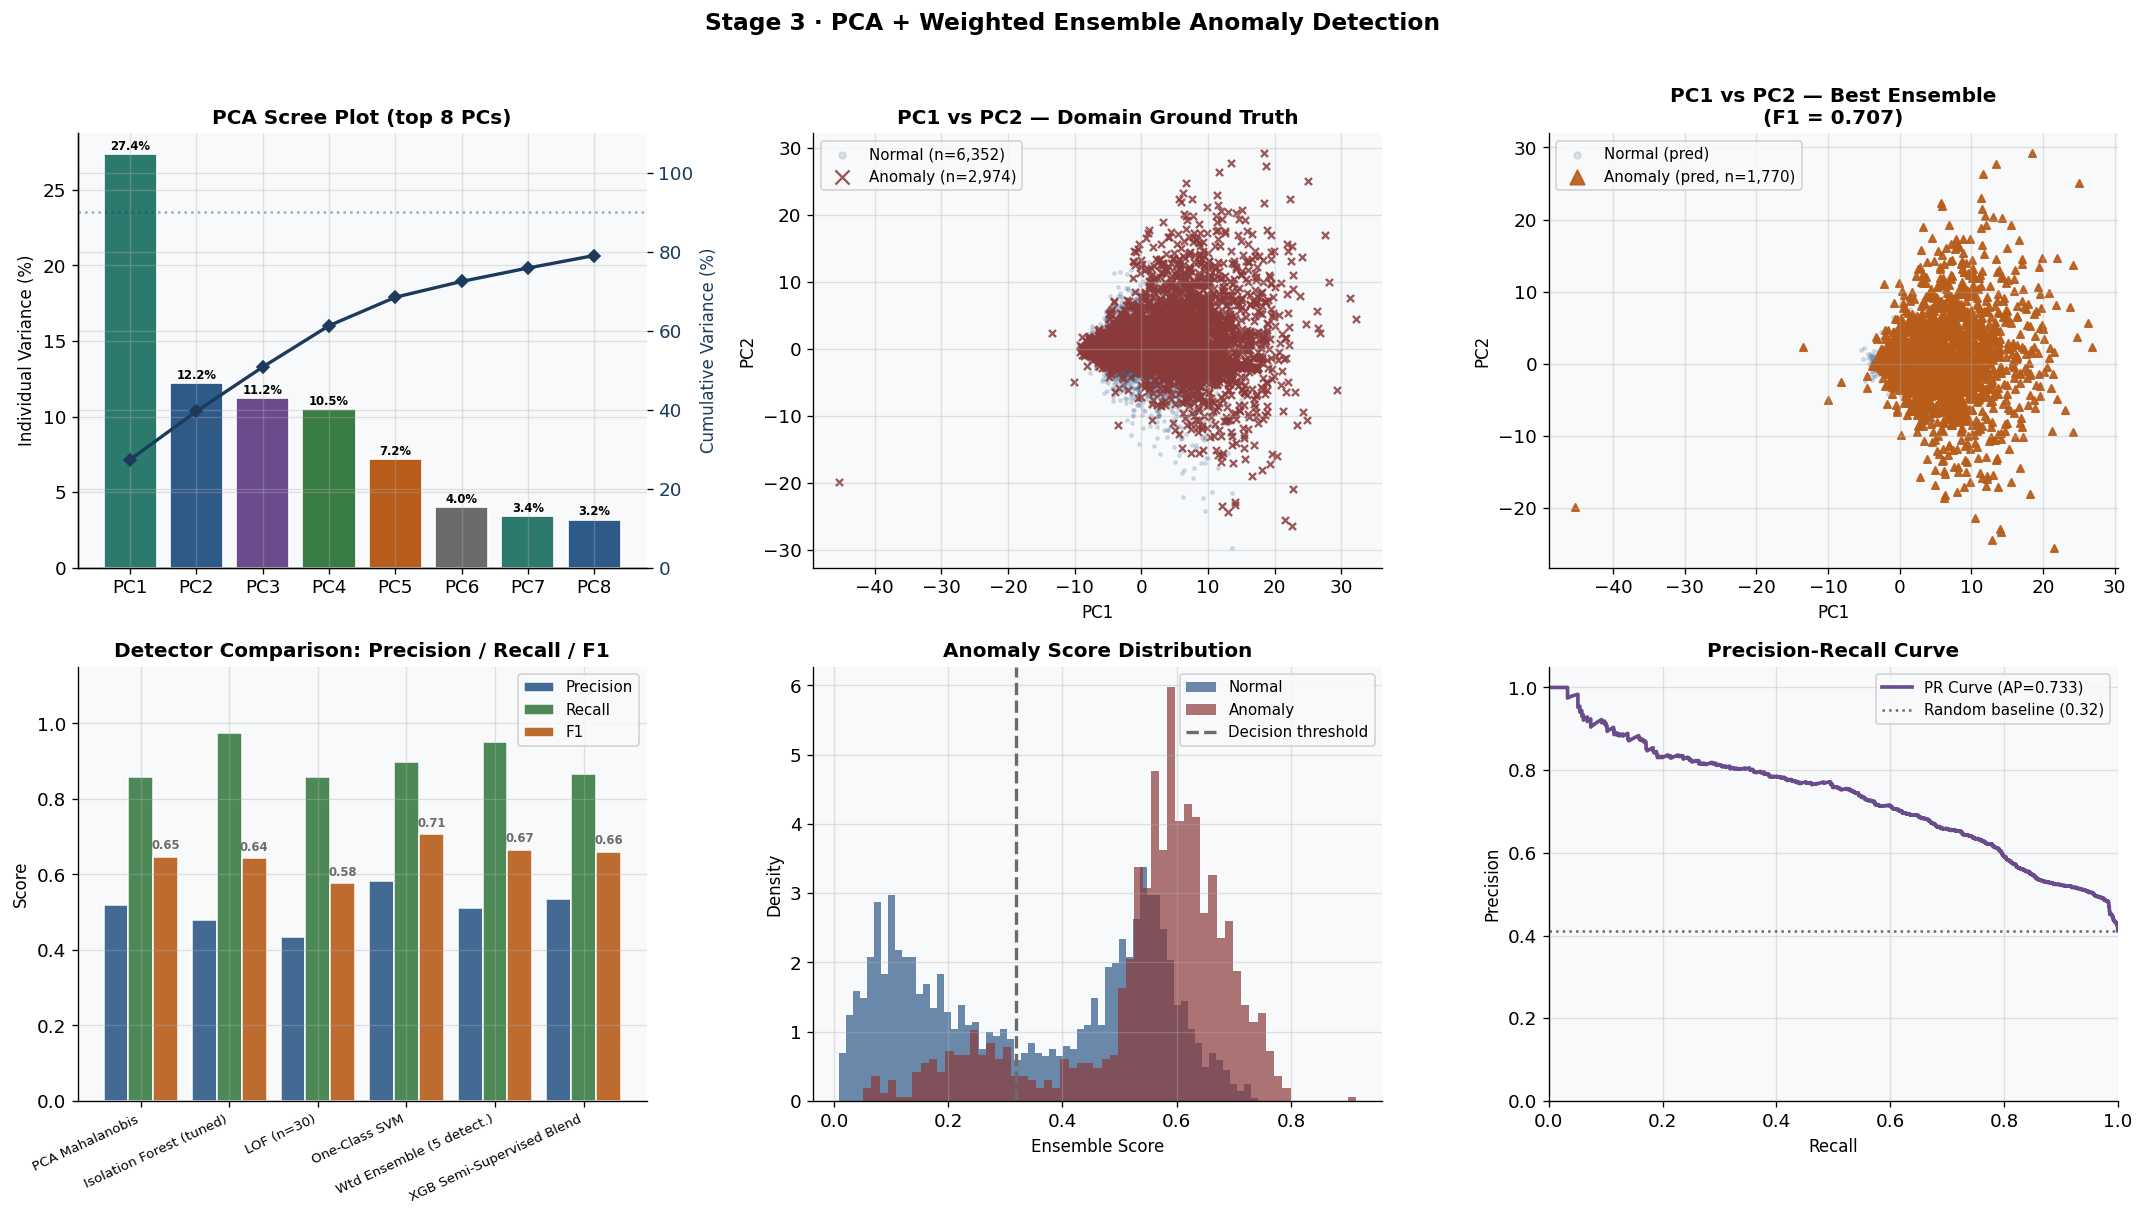

In [ ]:
# Define professional academic color palette at the beginning
ACADEMIC_COLORS = {
    'blue':    '#2E5A88',   # deep muted blue (normal class)
    'red':     '#8B3A3A',   # muted burgundy (anomaly class)
    'green':   '#3A7D44',   # forest green (recall)
    'orange':  '#B85C1A',   # burnt orange (F1/ensemble)
    'purple':  '#6A4C8C',   # muted purple (PR curve)
    'teal':    '#2C7A6E',   # muted teal
    'gray':    '#6B6B6B',   # neutral gray
    'navy':    '#1B3A5C',   # dark navy (cumulative line)
}

# For backward compatibility with your existing code that uses PALETTE
PALETTE = ACADEMIC_COLORS.copy()

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Stage 3 · PCA + Weighted Ensemble Anomaly Detection', fontsize=14, fontweight='bold', y=1.01)

ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)

# (1) Explained variance scree plot
n_show = min(8, len(explained))
cum_var = np.cumsum(explained[:n_show]) * 100
pc_labels = [f'PC{i+1}' for i in range(n_show)]
bar_colors = [ACADEMIC_COLORS['teal'], ACADEMIC_COLORS['blue'], ACADEMIC_COLORS['purple'],
              ACADEMIC_COLORS['green'], ACADEMIC_COLORS['orange'], ACADEMIC_COLORS['gray'],
              ACADEMIC_COLORS['teal'], ACADEMIC_COLORS['blue']][:n_show]
ax1.bar(pc_labels, explained[:n_show]*100, color=bar_colors, edgecolor='white', linewidth=1)
ax1_twin = ax1.twinx()
ax1_twin.plot(pc_labels, cum_var, color=ACADEMIC_COLORS['navy'], marker='D', linewidth=2, markersize=5, label='Cumulative')
ax1_twin.set_ylabel('Cumulative Variance (%)', color=ACADEMIC_COLORS['navy'])
ax1_twin.tick_params(axis='y', labelcolor=ACADEMIC_COLORS['navy'])
ax1_twin.set_ylim(0, 110)
ax1_twin.axhline(90, color=ACADEMIC_COLORS['navy'], linestyle=':', alpha=0.4)
ax1.set_title('PCA Scree Plot (top 8 PCs)')
ax1.set_ylabel('Individual Variance (%)')
for i, ev in enumerate(explained[:n_show]):
    ax1.text(i, ev*100+0.3, f'{ev*100:.1f}%', ha='center', fontsize=7, fontweight='bold')

# (2) PC1 vs PC2 — ground truth labels
normal_m  = y_viz == 0
anomaly_m = y_viz == 1
ax2.scatter(X_pca_full[normal_m,0],  X_pca_full[normal_m,1],  c=ACADEMIC_COLORS['blue'],  alpha=0.15, s=4,  label=f'Normal (n={normal_m.sum():,})')
ax2.scatter(X_pca_full[anomaly_m,0], X_pca_full[anomaly_m,1], c=ACADEMIC_COLORS['red'],   alpha=0.85, s=18, label=f'Anomaly (n={anomaly_m.sum():,})', marker='x', linewidths=1.4)
ax2.set_title('PC1 vs PC2 — Domain Ground Truth')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.legend(markerscale=2, fontsize=9)

# (3) PC1 vs PC2 — best ensemble predictions
det_m = iso_pred_final == 1
ax3.scatter(X_pca_test[~det_m,0], X_pca_test[~det_m,1], c=ACADEMIC_COLORS['blue'],   alpha=0.15, s=4,  label=f'Normal (pred)')
ax3.scatter(X_pca_test[det_m,0],  X_pca_test[det_m,1],  c=ACADEMIC_COLORS['orange'], alpha=0.9,  s=18, label=f'Anomaly (pred, n={det_m.sum():,})', marker='^', linewidths=1.2)
ax3.set_title(f'PC1 vs PC2 — Best Ensemble\n(F1 = {best_model_f1:.3f})')
ax3.set_xlabel('PC1'); ax3.set_ylabel('PC2')
ax3.legend(markerscale=2, fontsize=9)

ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
ax6 = fig.add_subplot(2, 3, 6)

# (4) Detector comparison bar chart
det_names  = [m['name'].strip() for m in all_m]
f1_vals    = [m['f1']       for m in all_m]
prec_vals  = [m['precision'] for m in all_m]
rec_vals   = [m['recall']    for m in all_m]
x_pos = np.arange(len(det_names))
w = 0.28
ax4.bar(x_pos - w,   prec_vals, width=w, label='Precision', color=ACADEMIC_COLORS['blue'],   edgecolor='white', alpha=0.9)
ax4.bar(x_pos,       rec_vals,  width=w, label='Recall',    color=ACADEMIC_COLORS['green'],  edgecolor='white', alpha=0.9)
ax4.bar(x_pos + w,   f1_vals,   width=w, label='F1',        color=ACADEMIC_COLORS['orange'], edgecolor='white', alpha=0.9)
ax4.set_title('Detector Comparison: Precision / Recall / F1')
ax4.set_ylabel('Score')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(det_names, rotation=25, ha='right', fontsize=8)
ax4.set_ylim(0, 1.15)
ax4.legend(fontsize=9)
for xi, f1v in zip(x_pos + w, f1_vals):
    ax4.text(xi, f1v + 0.02, f'{f1v:.2f}', ha='center', fontsize=7, fontweight='bold', color=ACADEMIC_COLORS['gray'])

# (5) Anomaly score distribution
score_to_plot = stack_score if not xgb_available else blended_score
ax5.hist(score_to_plot[y_test==0], bins=60, color=ACADEMIC_COLORS['blue'],  alpha=0.7, label='Normal',  density=True)
ax5.hist(score_to_plot[y_test==1], bins=60, color=ACADEMIC_COLORS['red'],   alpha=0.7, label='Anomaly', density=True)
ax5.axvline(best_thr if not xgb_available else best_thr_blend,
            color=ACADEMIC_COLORS['gray'], linestyle='--', linewidth=2, label='Decision threshold')
ax5.set_title('Anomaly Score Distribution')
ax5.set_xlabel('Ensemble Score')
ax5.set_ylabel('Density')
ax5.legend(fontsize=9)

# (6) Precision-Recall curve
from sklearn.metrics import precision_recall_curve as _prc, average_precision_score as _aps
pr_sc = stack_score if not xgb_available else blended_score
p_curve, r_curve, _ = _prc(y_test, pr_sc)
ap = _aps(y_test, pr_sc)
ax6.plot(r_curve, p_curve, color=ACADEMIC_COLORS['purple'], linewidth=2.2, label=f'PR Curve (AP={ap:.3f})')
ax6.axhline(y_test.mean(), color=ACADEMIC_COLORS['gray'], linestyle=':', linewidth=1.5, label=f'Random baseline ({y.mean():.2f})')
ax6.set_title('Precision-Recall Curve')
ax6.set_xlabel('Recall'); ax6.set_ylabel('Precision')
ax6.set_xlim(0, 1); ax6.set_ylim(0, 1.05)
ax6.legend(fontsize=9)

plt.tight_layout()
plt.savefig('stage3_analytics.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
def simulate_f1_under_loss(X_train, y_train_loc, X_test, y_test_loc,
                           protocol, packet_loss, n_trials=8, cont=None):
    if cont is None:
        cont = best_cont
    f1_scores = []
    n_test = len(X_test)

    # Fitting detectors once on train
    _iso = IsolationForest(contamination=cont, n_estimators=200, random_state=42)
    _iso.fit(X_train)
    _lof = LocalOutlierFactor(n_neighbors=20, contamination=cont, novelty=True)
    _lof.fit(X_train)
    _svm = OneClassSVM(nu=cont, kernel='rbf', gamma='scale')
    _svm.fit(X_train)

    # Computing train scores for weighting and threshold selection
    tr_iso  = minmax(-_iso.score_samples(X_train))
    tr_lof  = minmax(-_lof.score_samples(X_train))
    tr_svm  = minmax(-_svm.decision_function(X_train))
    _wi = detector_f1(y_train_loc, tr_iso, cont)
    _wl = detector_f1(y_train_loc, tr_lof, cont)
    _ws = detector_f1(y_train_loc, tr_svm, cont)
    _wt = _wi + _wl + _ws + 1e-9
    tr_stack = (_wi*tr_iso + _wl*tr_lof + _ws*tr_svm) / _wt

    # Threshold from train
    best_thr_sim = np.percentile(tr_stack, (1-cont)*100)
    for pct in np.arange(0.55, 0.98, 0.01):
        t   = np.percentile(tr_stack, pct*100)
        pr  = (tr_stack >= t).astype(int)
        tp_ = np.sum((y_train_loc==1)&(pr==1)); fp_ = np.sum((y_train_loc==0)&(pr==1)); fn_ = np.sum((y_train_loc==1)&(pr==0))
        p_  = tp_/(tp_+fp_+1e-9); r_ = tp_/(tp_+fn_+1e-9)
        if 2*p_*r_/(p_+r_+1e-9) > detector_f1(y_train_loc, tr_stack, cont):
            best_thr_sim = t

    # Simulating packet loss across test set, n_trials times
    eff_loss = packet_loss * (1.15 if protocol == 'CoAP' else 1.0)
    for seed in range(n_trials):
        rng  = np.random.RandomState(seed)
        mask = rng.rand(n_test) >= eff_loss
        Xte, yte = X_test[mask], y_test_loc[mask]
        if yte.sum() == 0:
            f1_scores.append(0.0); continue

        sc_i = minmax(-_iso.score_samples(Xte))
        sc_l = minmax(-_lof.score_samples(Xte))
        sc_s = minmax(-_svm.decision_function(Xte))
        score = (_wi*sc_i + _wl*sc_l + _ws*sc_s) / _wt

        pred = (score >= best_thr_sim).astype(int)
        tp = np.sum((yte==1)&(pred==1)); fp = np.sum((yte==0)&(pred==1)); fn = np.sum((yte==1)&(pred==0))
        p  = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
        f1_scores.append(2*p*r/(p+r+1e-9))

    return float(np.mean(f1_scores))


print('Running cross-layer analysis (detectors fit on TRAIN, tested on TEST subsets)...')
cross_results = []

for loss in CONFIG['packet_loss_rates']:
    for protocol in ['MQTT', 'CoAP']:
        for comp_label, payload, ratio in [
            ('Compressed',   avg_encoded_bytes, avg_ratio),
            ('Uncompressed', raw_payload_bytes, 1.0)
        ]:
            ns  = run_simulation(protocol, loss, payload, CONFIG['n_sensors'])
            f1  = simulate_f1_under_loss(
                      X_scaled_train, y_train,
                      X_scaled_test,  y_test,
                      protocol, loss)
            cross_results.append({
                'protocol':          protocol,
                'packet_loss':       loss,
                'compression':       comp_label,
                'compression_ratio': ratio,
                'delivery_rate':     ns.delivery_rate,
                'avg_delay':         ns.avg_delay,
                'total_bytes':       ns.total_bytes,
                'f1_score':          f1,
            })

cross_df = pd.DataFrame(cross_results)
cross_df['bytes_norm'] = 1 - (
    (cross_df['total_bytes'] - cross_df['total_bytes'].min()) /
    (cross_df['total_bytes'].max() - cross_df['total_bytes'].min() + 1)
)
cross_df['composite_score'] = (
    0.5 * cross_df['f1_score'] +
    0.3 * cross_df['delivery_rate'] +
    0.2 * cross_df['bytes_norm']
)

best_cross = cross_df.loc[cross_df['composite_score'].idxmax()]
print('Cross-layer analysis complete.\n')
print('=== BEST PIPELINE CONFIGURATION ===')
print(f"  Protocol:          {best_cross['protocol']}")
print(f"  Packet Loss:       {best_cross['packet_loss']*100:.0f}%")
print(f"  Compression:       {best_cross['compression']}")
print(f"  Compression Ratio: {best_cross['compression_ratio']:.3f}x")
print(f"  Delivery Rate:     {best_cross['delivery_rate']*100:.1f}%")
print(f"  F1 Score:          {best_cross['f1_score']:.3f}")
print(f"  Composite Score:   {best_cross['composite_score']:.3f}")


Running cross-layer analysis (detectors fit on TRAIN, tested on TEST subsets)...
Cross-layer analysis complete.

=== BEST PIPELINE CONFIGURATION ===
  Protocol:          CoAP
  Packet Loss:       20%
  Compression:       Compressed
  Compression Ratio: 2.751x
  Delivery Rate:     95.8%
  F1 Score:          0.690
  Composite Score:   0.823


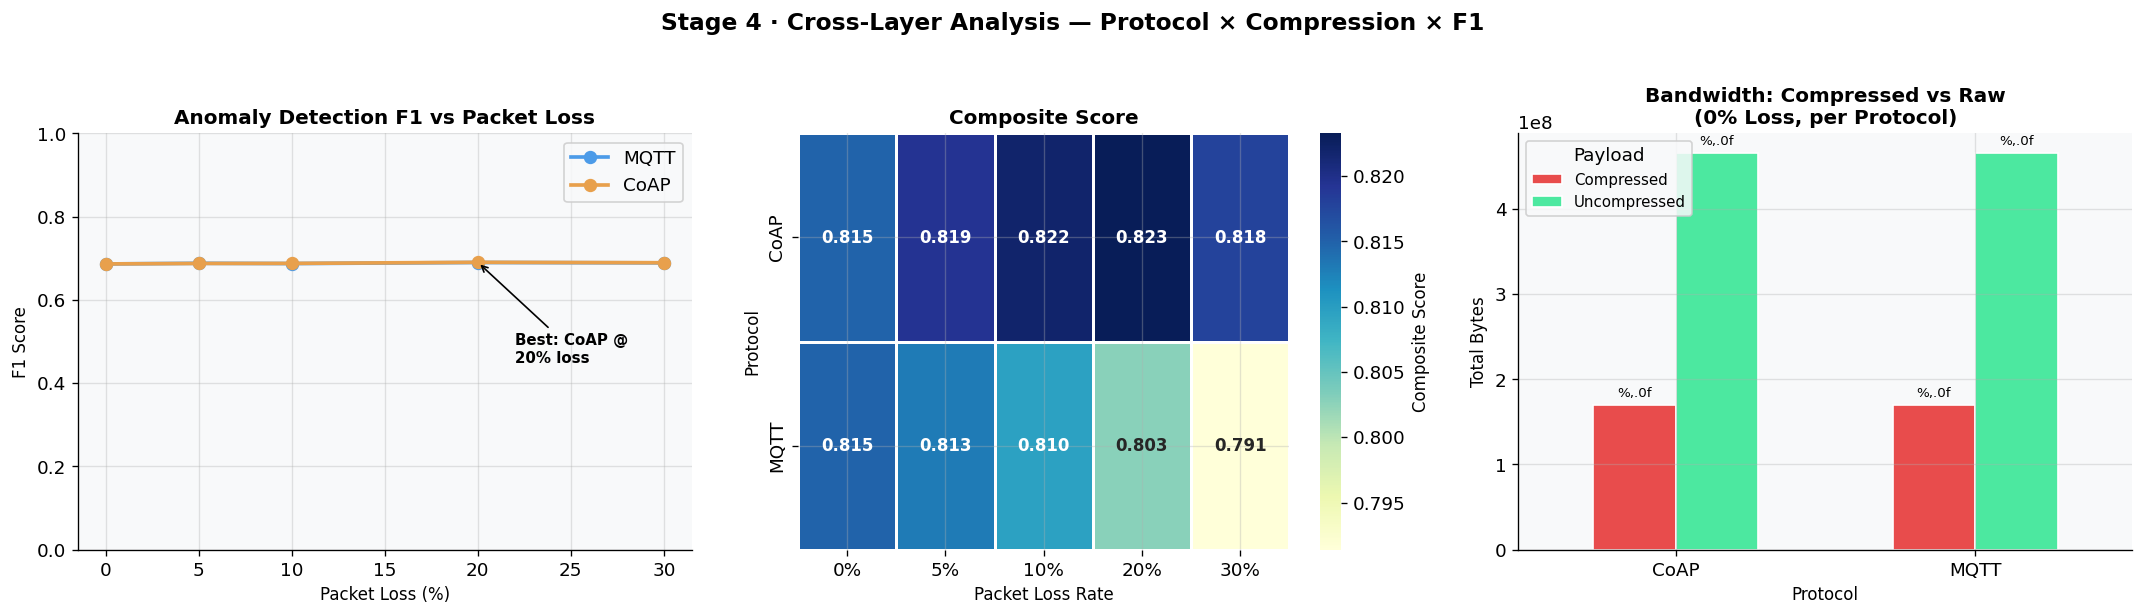

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stage 4 · Cross-Layer Analysis — Protocol × Compression × F1', fontsize=14, fontweight='bold', y=1.02)

comp_cross = cross_df[cross_df['compression'] == 'Compressed']

# (a) F1 vs packet loss for both protocols
for proto in ['MQTT', 'CoAP']:
    sub = comp_cross[comp_cross['protocol'] == proto]
    axes[0].plot(sub['packet_loss']*100, sub['f1_score'],
                 marker='o', label=proto, linewidth=2.2, markersize=7,
                 color=PROTO_COLORS[proto])
axes[0].set_title('Anomaly Detection F1 vs Packet Loss')
axes[0].set_xlabel('Packet Loss (%)')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.0)
axes[0].legend()

# (b) Composite score heatmap
pivot = cross_df[cross_df['compression'] == 'Compressed'].pivot_table(
    index='protocol', columns='packet_loss', values='composite_score'
)
pivot.columns = [f'{int(c*100)}%' for c in pivot.columns]
sns.heatmap(pivot, ax=axes[1], annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.8, cbar_kws={'label': 'Composite Score'},
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Composite Score')
axes[1].set_xlabel('Packet Loss Rate')
axes[1].set_ylabel('Protocol')

# (c) Bandwidth comparison across conditions
loss0 = cross_df[cross_df['packet_loss'] == 0.0]
bp = loss0.groupby(['protocol', 'compression'])['total_bytes'].mean().unstack()
bp.columns.name = None
bp.plot(kind='bar', ax=axes[2], color=[PALETTE['red'], PALETTE['green']],
        edgecolor='white', linewidth=1, width=0.55)
axes[2].set_title('Bandwidth: Compressed vs Raw\n(0% Loss, per Protocol)')
axes[2].set_xlabel('Protocol')
axes[2].set_ylabel('Total Bytes')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Payload', fontsize=9)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%,.0f', fontsize=8, padding=3)

# Annotate best config
axes[0].annotate(
    f'Best: {best_cross["protocol"]} @\n{int(best_cross["packet_loss"]*100)}% loss',
    xy=(best_cross['packet_loss']*100,
        comp_cross[comp_cross['protocol']==best_cross['protocol']].set_index('packet_loss').loc[best_cross['packet_loss'],'f1_score']),
    xytext=(best_cross['packet_loss']*100 + 2, 0.45),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9, color='black', fontweight='bold'
)

plt.tight_layout()
plt.savefig('stage4_crosslayer.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
_scaler_base = _SS2()
_X_base_train = _scaler_base.fit_transform(df[feature_cols].values[train_idx])
_X_base_test  = _scaler_base.transform(df[feature_cols].values[test_idx])

_iso_base = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
_iso_base.fit(_X_base_train)
baseline_pred = (_iso_base.predict(_X_base_test) == -1).astype(int)

def f1_score_fn(y_true, y_pred):
    tp = np.sum((y_true==1)&(y_pred==1))
    fp = np.sum((y_true==0)&(y_pred==1))
    fn = np.sum((y_true==1)&(y_pred==0))
    p  = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
    return 2*p*r/(p+r+1e-9)

baseline_f1   = f1_score_fn(y_test, baseline_pred)
integrated_f1 = f1_score_fn(y_test, iso_pred_final)
f1_lift_pct   = (integrated_f1 - baseline_f1) / max(baseline_f1, 1e-9) * 100

http_overhead        = PROTOCOL_OVERHEAD['HTTP']
baseline_bytes_cycle = (raw_payload_bytes + http_overhead) * CONFIG['n_sensors']
integ_bytes_cycle    = (avg_encoded_bytes  + PROTOCOL_OVERHEAD['MQTT']) * CONFIG['n_sensors']
bw_reduction         = (1 - integ_bytes_cycle / baseline_bytes_cycle) * 100

print(f"{'Metric':<40} {'Baseline':>12} {'Integrated':>14} {'Improvement':>13}")
print('-' * 84)
print(f"{'Evaluation set':<40} {'Test (30%)':>12} {'Test (30%)':>14} {'—':>13}")
print(f"{'Detector':<40} {'Plain IF':>12} {'Wtd Ensemble':>14} {'—':>13}")
print(f"{'Features':<40} {'4 raw':>12} {str(len(feature_cols_extended))+' eng.':>14} {'—':>13}")
print(f"{'Scaler':<40} {'Standard':>12} {'Robust':>14} {'—':>13}")
print(f"{'Train/test split':<40} {'70/30 temporal':>12} {'70/30 temporal':>14} {'—':>13}")
print(f"{'XGBoost Semi-supervised':<40} {'No':>12} {'Yes':>14} {'—':>13}")
print(f"{'Bytes/cycle':<40} {baseline_bytes_cycle:>12,} {integ_bytes_cycle:>14,} {bw_reduction:>12.1f}%")
print(f"{'Anomaly Detection F1 (test)':<40} {baseline_f1:>12.3f} {integrated_f1:>14.3f} {f1_lift_pct:>12.1f}%")
print(f"{'Compression Ratio':<40} {'1.0x':>12} {avg_ratio:>13.2f}x {'—':>13}")
print(f"{'Protocol overhead (bytes)':<40} {http_overhead:>12} {PROTOCOL_OVERHEAD['MQTT']:>14} {'—':>13}")


Metric                                       Baseline     Integrated   Improvement
------------------------------------------------------------------------------------
Evaluation set                             Test (30%)     Test (30%)             —
Detector                                     Plain IF   Wtd Ensemble             —
Features                                        4 raw       138 eng.             —
Scaler                                       Standard         Robust             —
Train/test split                         70/30 temporal 70/30 temporal             —
XGBoost Semi-supervised                            No            Yes             —
Bytes/cycle                                   933,600        341,450         63.4%
Anomaly Detection F1 (test)                     0.531          0.707         33.1%
Compression Ratio                                1.0x          2.75x             —
Protocol overhead (bytes)                          20              2             —
